In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/clar04/alldata-split/dataset_with_split.csv


# M2 — CABiLSTM-IndoBERT (Multilabel Wide Format)

**Implementation of CABiLSTM-BERT (He et al., 2025) adapted for Indonesian multilabel ABSA.**

## Architecture:
```
Input: [CLS] review_text [SEP]
  │
  ▼
IndoBERT (FROZEN) ──────────────► V  [B, L, 768]
  │
  ▼
BiLSTM Layer 1 ─────────────────► F1, B1  [B, L, 768]
  │
  ▼
BiLSTM Layer 2 ─────────────────► F2, B2  [B, L, 768]
  │
  ▼
Multi-Head Self-Attention (8h) ──► A1..A5 per feature group
  │
  ▼
Channel Concat + Conv2d (5→1) ───► Co  [B, L, 768]
  │
  ▼
Mean Pooling ────────────────────► M  [B, 768]
  │
  ▼
MLP: 1024 → 512 → 15 outputs
```

## Key differences from M1:
| Component | M1 | M2 |
|---|---|---|
| BERT strategy | Full fine-tune | **Frozen** |
| Learning rate | 2e-5 | **5e-4** |
| Middle layer | None | **CABiLSTM** |
| Pooling | `[CLS]` token | **Mean pooling** |
| Classifier | Linear(768→15) | **MLP: 1024→512→15** |



---
## Section 1: Setup & Imports

In [2]:
import os, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')

PyTorch  : 2.10.0+cu128
CUDA     : True


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


---
## Section 2: Configuration & Constants

In [4]:
CONFIG = {
    # Model
    'model_name'       : 'indobenchmark/indobert-base-p1',
    'freeze_bert'      : True,      
    'num_outputs'      : 4,        
    'dropout'          : 0.3,
    # Tokenization
    'max_length'       : 128,      
    # Training
    'batch_size'       : 16,
    'learning_rate'    : 5e-4,      
    'weight_decay'     : 0.01,
    'epochs'           : 10,
    'patience'         : 3,
    'warmup_ratio'     : 0.1,
    'grad_clip'        : 1.0,
    # CABiLSTM architecture (He et al., 2025 Section 4.2)
    'bilstm_hidden'    : 384,       # 384×2 bidirectional = 768, matches BERT
    'bilstm_layers'    : 2,         # Fig. 4 optimal
    'attn_heads'       : 8,         # Fig. 5 optimal
    'conv_kernel'      : 5,         # Section 4.2
    'mlp_hidden_1'     : 1024,      # Section 3.4
    'mlp_hidden_2'     : 512,       # Section 3.4
    'seed'             : SEED,
}

ASPECTS    = ['PIGMENTATION', 'LONGEVITY', 'TEXTURE', 'HYDRATION', 'PRICE']
SENTIMENTS = ['no_aspect', 'negative', 'neutral', 'positive']  # index 0, 1, 2, 3  
SENT2ID    = {s: i for i, s in enumerate(SENTIMENTS)}
ID2SENT    = {i: s for s, i in SENT2ID.items()}

DATA_PATH           = '/kaggle/input/datasets/clar04/alldata-split/dataset_with_split.csv'
OUTPUT_DIR          = '/kaggle/working'
BEST_MODEL_PATH     = f'{OUTPUT_DIR}/m2_labels-4cls_best.pt'
PREDICTIONS_PATH    = f'{OUTPUT_DIR}/m2_labels-4cls_predictions.csv'
METRICS_PATH        = f'{OUTPUT_DIR}/m2_labels-4cls_metrics.json'
LOSS_PLOT_PATH      = f'{OUTPUT_DIR}/m2_labels-4cls_loss_convergence.png'
CM_PLOT_PATH        = f'{OUTPUT_DIR}/m2_labels-4cls_confusion_matrix.png'
PERASPECT_PLOT_PATH = f'{OUTPUT_DIR}/m2_labels-4cls_per_aspect_results.png'

assert os.path.exists(DATA_PATH), f'Dataset not found: {DATA_PATH}'
print('Config loaded.')
for k, v in CONFIG.items():
    print(f'  {k:<18} {v}')

Config loaded.
  model_name         indobenchmark/indobert-base-p1
  freeze_bert        True
  num_outputs        4
  dropout            0.3
  max_length         128
  batch_size         16
  learning_rate      0.0005
  weight_decay       0.01
  epochs             10
  patience           3
  warmup_ratio       0.1
  grad_clip          1.0
  bilstm_hidden      384
  bilstm_layers      2
  attn_heads         8
  conv_kernel        5
  mlp_hidden_1       1024
  mlp_hidden_2       512
  seed               42


---
## Section 3: Load Data & EDA

In [5]:
df = pd.read_csv(DATA_PATH)
print(f'Total rows : {len(df)}')
print('Split distribution:')
print(df['split'].value_counts().to_string())
display(df.head(3))

Total rows : 1098
Split distribution:
split
train    998
val       50
test      50


,review_id,review_text,product_name,product_brand,PIGMENTATION,LONGEVITY,TEXTURE,HYDRATION,PRICE,is_synthetic,source_fase,method,split
0,388,"Aku kira bakalan aroma strawberrynya kuat, ter...",24H Melt-In Moisture,Nivea,no_aspect,no_aspect,no_aspect,positive,no_aspect,False,NaN,NaN,train
1,334,Beli produk ini tuh awalnya karena IKON hahaha...,24H Melt-In Moisture,Nivea,positive,no_aspect,no_aspect,positive,no_aspect,False,NaN,NaN,train
2,142,My favorit lip balm!! enggak bikin bibir kerin...,24H Melt-In Moisture,Nivea,neutral,no_aspect,positive,positive,no_aspect,False,NaN,NaN,train


In [6]:
print('Label distribution per aspect (train set):')
train_df = df[df['split'] == 'train']
print(f'{"Aspect":<14} {"positive":>9} {"negative":>9} {"neutral":>9} {"no_aspect":>10} {"imb_ratio":>10}')
print('-' * 65)
for asp in ASPECTS:
    counts  = train_df[asp].value_counts()
    pos     = counts.get('positive',  0)
    neg     = counts.get('negative',  0)
    neu     = counts.get('neutral',   0)
    noa     = counts.get('no_aspect', 0)
    sents   = [c for c in [pos, neg, neu] if c > 0]
    ratio   = max(sents) / min(sents) if sents else 0
    print(f'{asp:<14} {pos:>9} {neg:>9} {neu:>9} {noa:>10} {ratio:>9.1f}:1')

Label distribution per aspect (train set):
Aspect          positive  negative   neutral  no_aspect  imb_ratio
-----------------------------------------------------------------
PIGMENTATION         377        98       172        351       3.8:1
LONGEVITY             93       193        40        672       4.8:1
TEXTURE              272       114        41        571       6.6:1
HYDRATION            584       176        85        153       6.9:1
PRICE                252        20        11        715      22.9:1


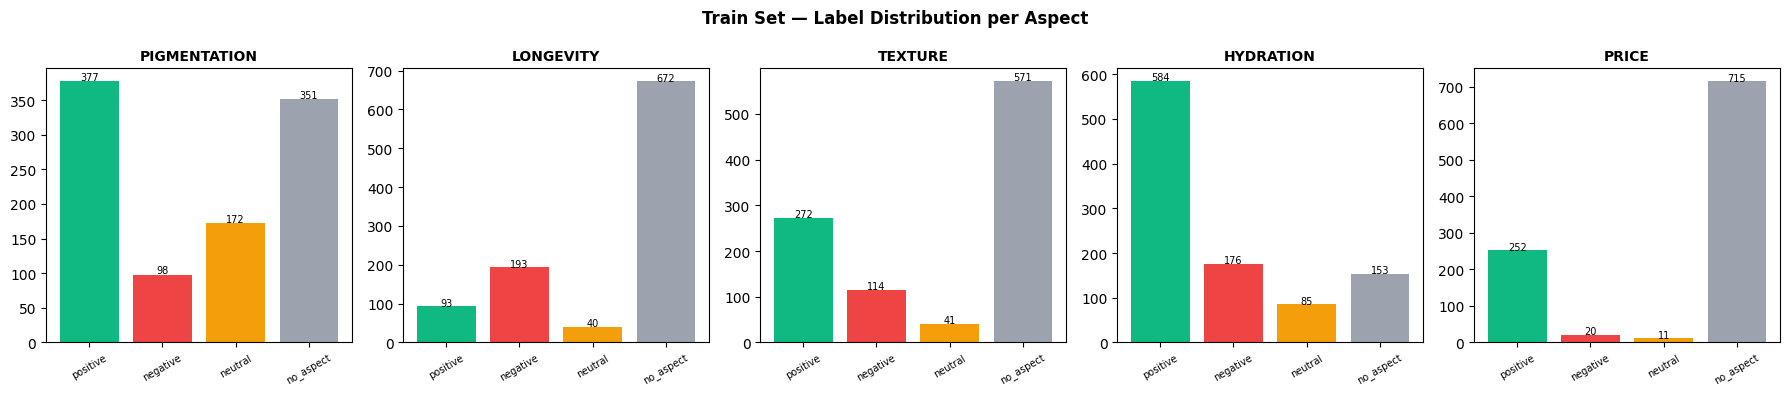

In [7]:
SENT_COLORS = {'negative': '#ef4444', 'neutral': '#f59e0b',
               'positive': '#10b981', 'no_aspect': '#9ca3af'}

fig, axes = plt.subplots(1, len(ASPECTS), figsize=(18, 4), sharey=False)
for ax, asp in zip(axes, ASPECTS):
    counts = train_df[asp].value_counts().reindex(
        ['positive', 'negative', 'neutral', 'no_aspect'], fill_value=0
    )
    bars = ax.bar(counts.index, counts.values,
                  color=[SENT_COLORS[l] for l in counts.index])
    ax.set_title(asp, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, str(v),
                ha='center', fontsize=7)
plt.suptitle('Train Set — Label Distribution per Aspect', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4: Tokenizer & Dataset

In [8]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f'Tokenizer : {CONFIG["model_name"]}')
print(f'Vocab size: {tokenizer.vocab_size:,}')

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer : indobenchmark/indobert-base-p1
Vocab size: 30,521


In [9]:
class ABSADataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 128):
        self.df         = df.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        enc = self.tokenizer(
            str(row['review_text']),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )

        # CE: label integer (5,) bukan one-hot (15,)
        labels = torch.zeros(5, dtype=torch.long)
        for asp_idx, asp in enumerate(ASPECTS):
            labels[asp_idx] = SENT2ID[row[asp]]

        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc['token_type_ids'].squeeze(0),
            'labels'        : labels,
            'review_id'     : str(row['review_id']),
        }

In [10]:
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'  ].reset_index(drop=True)
test_df  = df[df['split'] == 'test' ].reset_index(drop=True)

train_ds = ABSADataset(train_df, tokenizer, CONFIG['max_length'])
val_ds   = ABSADataset(val_df,   tokenizer, CONFIG['max_length'])
test_ds  = ABSADataset(test_df,  tokenizer, CONFIG['max_length'])

print(f'Train : {len(train_ds)} reviews')
print(f'Val   : {len(val_ds)} reviews')
print(f'Test  : {len(test_ds)} reviews')

s = train_ds[0]
print(f'Sample 0 labels: {[(ASPECTS[i], SENTIMENTS[s["labels"][i].item()]) for i in range(5)]}')

Train : 998 reviews
Val   : 50 reviews
Test  : 50 reviews
Sample 0 labels: [('PIGMENTATION', 'no_aspect'), ('LONGEVITY', 'no_aspect'), ('TEXTURE', 'no_aspect'), ('HYDRATION', 'positive'), ('PRICE', 'no_aspect')]


---
## Section 5: DataLoader

In [11]:
def collate_fn(batch):
    return {
        'input_ids'     : torch.stack([b['input_ids']      for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'token_type_ids': torch.stack([b['token_type_ids'] for b in batch]),
        'labels'        : torch.stack([b['labels']         for b in batch]),
        'review_id'     : [b['review_id'] for b in batch],
    }

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')

b = next(iter(train_loader))
print('\nBatch shapes:')
for k in ['input_ids', 'attention_mask', 'token_type_ids', 'labels']:
    print(f'  {k:<16}: {b[k].shape}  dtype={b[k].dtype}')

Train batches: 63
Val   batches: 4
Test  batches: 4

Batch shapes:
  input_ids       : torch.Size([16, 128])  dtype=torch.int64
  attention_mask  : torch.Size([16, 128])  dtype=torch.int64
  token_type_ids  : torch.Size([16, 128])  dtype=torch.int64
  labels          : torch.Size([16, 5])  dtype=torch.int64


---
## Section 6: Model Definition — CABiLSTM-IndoBERT

In [12]:
class CABiLSTMCore(nn.Module):
    def __init__(self, hidden_dim: int = 768, bilstm_hidden: int = 384,
                 num_heads: int = 8, conv_kernel: int = 5):
        super().__init__()

        # Two independent BiLSTM layers to capture per-layer outputs
        self.bilstm1 = nn.LSTM(hidden_dim, bilstm_hidden, num_layers=1,
                               bidirectional=True, batch_first=True)
        self.bilstm2 = nn.LSTM(hidden_dim, bilstm_hidden, num_layers=1,
                               bidirectional=True, batch_first=True)

        # Shared MHSA applied independently to each feature group
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads,
            dropout=0.0, batch_first=True,
        )

        # 2D conv: merge 5 channel groups → 1
        # Input:  [B, 5, L, hidden_dim]
        # Output: [B, 1, L, hidden_dim]
        pad = conv_kernel // 2
        self.conv = nn.Conv2d(in_channels=5, out_channels=1,
                              kernel_size=conv_kernel, padding=pad)

    def _split_bidirectional(self, out: torch.Tensor) -> tuple:
        """Split BiLSTM output into forward/backward, each padded to full hidden_dim."""
        half = out.size(-1) // 2
        fwd  = out[..., :half]                   # [B, L, bilstm_hidden]
        bwd  = out[..., half:]
        # Repeat to restore full hidden_dim (768) so all groups have same shape
        return torch.cat([fwd, fwd], dim=-1), torch.cat([bwd, bwd], dim=-1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Stage 1: Dual-layer BiLSTM
        out1, _ = self.bilstm1(x)                # [B, L, 768]
        F1, B1  = self._split_bidirectional(out1)

        out2, _ = self.bilstm2(out1)             # [B, L, 768]
        F2, B2  = self._split_bidirectional(out2)

        # Stage 2: MHSA on each of 5 feature groups
        attended = [
            self.attention(fg, fg, fg)[0]
            for fg in [x, F1, B1, F2, B2]
        ]  # list of 5 × [B, L, 768]

        # Stage 3: Channel-wise concat + Conv2d + ReLU
        Ao = torch.stack(attended, dim=1)        # [B, 5, L, 768]
        Co = F.relu(self.conv(Ao).squeeze(1))    # [B, L, 768]
        return Co

In [13]:
class M2_CABiLSTM_IndoBERT(nn.Module):
    def __init__(self, config: dict):
        super().__init__()
        self.bert = AutoModel.from_pretrained(config['model_name'])
        if config['freeze_bert']:
            for p in self.bert.parameters():
                p.requires_grad = False

        hidden_dim = self.bert.config.hidden_size  # 768

        self.cabilstm = CABiLSTMCore(
            hidden_dim    = hidden_dim,
            bilstm_hidden = config['bilstm_hidden'],
            num_heads     = config['attn_heads'],
            conv_kernel   = config['conv_kernel'],
        )

        # nn.Sequential hanya berisi layer — tidak ada assignment di sini
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim,             config['mlp_hidden_1']),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(config['mlp_hidden_1'], config['mlp_hidden_2']),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(config['mlp_hidden_2'], len(ASPECTS) * 4),
        )

        self._init_weights()

    def _init_weights(self):
        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, input_ids, attention_mask, token_type_ids):
        with torch.no_grad():
            V = self.bert(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
            ).last_hidden_state                              # [B, L, 768]

        Co = self.cabilstm(V)                               # [B, L, 768]

        mask_expand = attention_mask.unsqueeze(-1).float()  # [B, L, 1]
        M = (Co * mask_expand).sum(dim=1) / mask_expand.sum(dim=1).clamp(min=1)
        # [B, 768]

        out = self.classifier(M)                            # (B, 20)
        return out.view(-1, 5, 4)                           # (B, 5, 4)

In [14]:
model = M2_CABiLSTM_IndoBERT(CONFIG).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total:>14,}')
print(f'Trainable params : {trainable:>14,}  ({100*trainable/total:.1f}%)')
print(f'Frozen params    : {total-trainable:>14,}  ({100*(total-trainable)/total:.1f}%)')

# Forward pass sanity check
model.eval()
with torch.no_grad():
    sample = next(iter(train_loader))
    logits = model(sample['input_ids'].to(device),
                   sample['attention_mask'].to(device),
                   sample['token_type_ids'].to(device))
    print(f'Output shape     : {logits.shape}  (expected: [{CONFIG["batch_size"]}, 5, 4])')
    print(f'Any NaN          : {torch.isnan(logits).any().item()}')

if torch.cuda.is_available():
    print(f'GPU allocated    : {torch.cuda.memory_allocated(device)/1e9:.2f} GB')
    torch.cuda.empty_cache()

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Total params     :    135,216,530
Trainable params :     10,775,186  (8.0%)
Frozen params    :    124,441,344  (92.0%)
Output shape     : torch.Size([16, 5, 4])  (expected: [16, 5, 4])
Any NaN          : False
GPU allocated    : 0.55 GB


---
## Section 7: Loss Function, Optimizer & Scheduler

In [15]:
def ce_loss(logits, labels):
    """
    CrossEntropyLoss untuk output (B, 5, 4).
    logits : (B, 5, 4) raw model output
    labels : (B, 5)    integer class index (0=no_aspect, 1=neg, 2=neu, 3=pos)
    """
    B = logits.size(0)
    return F.cross_entropy(
        logits.view(B * 5, 4),
        labels.view(B * 5),
        label_smoothing=0.05,
        reduction='mean'
    )

In [16]:
# Only trainable params in optimizer (frozen BERT excluded automatically)
no_decay = ['bias', 'LayerNorm.weight']
optimizer_params = [
    {'params': [p for n, p in model.named_parameters()
                if p.requires_grad and not any(nd in n for nd in no_decay)],
     'weight_decay': CONFIG['weight_decay']},
    {'params': [p for n, p in model.named_parameters()
                if p.requires_grad and any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
]
optimizer = torch.optim.AdamW(optimizer_params, lr=CONFIG['learning_rate'])

total_steps  = len(train_loader) * CONFIG['epochs']
warmup_steps = int(CONFIG['warmup_ratio'] * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)

print(f'Optimizer    : AdamW  lr={CONFIG["learning_rate"]}  wd={CONFIG["weight_decay"]}')
print(f'Total steps  : {total_steps}')
print(f'Warmup steps : {warmup_steps}')
print(f'Loss         : CrossEntropyLoss (4-class, no masking)')
print(f'BERT frozen  : {CONFIG["freeze_bert"]}')

Optimizer    : AdamW  lr=0.0005  wd=0.01
Total steps  : 630
Warmup steps : 63
Loss         : CrossEntropyLoss (4-class, no masking)
BERT frozen  : True


---
## Section 8: Metric Helpers

In [17]:
def preds_from_logits(logits: torch.Tensor) -> np.ndarray:
    return torch.argmax(logits, dim=-1).cpu().numpy()   # (B, 5)

def labels_from_tensor(labels: torch.Tensor) -> np.ndarray:
    return labels.cpu().numpy()   # (B, 5)

def compute_metrics(all_true: np.ndarray, all_pred: np.ndarray) -> dict:
    t, p = all_true.flatten(), all_pred.flatten()
    return {
        'macro_f1'  : f1_score(t, p, average='macro', zero_division=0),
        'macro_prec': precision_score(t, p, average='macro', zero_division=0),
        'macro_rec' : recall_score(t, p, average='macro', zero_division=0),
        'accuracy'  : accuracy_score(t, p),
    }

def compute_per_aspect_metrics(all_true: np.ndarray, all_pred: np.ndarray) -> list:
    results = []
    for i, asp in enumerate(ASPECTS):
        t, p = all_true[:, i], all_pred[:, i]
        n    = len(t)
        f1   = f1_score(t, p, average='macro', zero_division=0)
        prec = precision_score(t, p, average='macro', zero_division=0)
        rec  = recall_score(t, p, average='macro', zero_division=0)
        acc  = accuracy_score(t, p)
        results.append({'aspect': asp, 'f1': f1, 'precision': prec,
                        'recall': rec, 'accuracy': acc, 'n_active': n})
    return results

---
## Section 9: Training & Validation Loop

In [18]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    all_true, all_pred = [], []

    for batch in tqdm(loader, desc='Train', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, token_type_ids)
        loss   = ce_loss(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_true.append(labels_from_tensor(labels.cpu()))
        all_pred.append(preds_from_logits(logits.detach().cpu()))

    all_true = np.vstack(all_true)
    all_pred = np.vstack(all_pred)
    return total_loss / len(loader), compute_metrics(all_true, all_pred)


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    all_true, all_pred = [], []

    for batch in tqdm(loader, desc='Eval ', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)

        logits      = model(input_ids, attention_mask, token_type_ids)
        total_loss += ce_loss(logits, labels).item()    # fix: akumulasi loss
        all_true.append(labels_from_tensor(labels.cpu()))
        all_pred.append(preds_from_logits(logits.detach().cpu()))

    all_true = np.vstack(all_true)
    all_pred = np.vstack(all_pred)
    return total_loss / len(loader), compute_metrics(all_true, all_pred), all_true, all_pred
    
print('Train/eval functions defined.')

Train/eval functions defined.


In [19]:
history = {'train_loss': [], 'val_loss': [],
           'train_f1'  : [], 'val_f1'  : []}

best_val_f1      = 0.0
best_epoch       = 0
patience_counter = 0

print('=== Training ===')
for epoch in range(CONFIG['epochs']):
    t0 = time.time()

    train_loss, train_m          = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss,   val_m, _, _      = eval_epoch(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['val_loss'  ].append(val_loss)
    history['train_f1'  ].append(train_m['macro_f1'])
    history['val_f1'    ].append(val_m['macro_f1'])

    print(f"Ep {epoch+1:02d}/{CONFIG['epochs']} "
          f"| TrLoss {train_loss:.4f}  ValLoss {val_loss:.4f} "
          f"| TrF1 {train_m['macro_f1']:.4f}  ValF1 {val_m['macro_f1']:.4f} "
          f"| {time.time()-t0:.1f}s")

    if val_m['macro_f1'] > best_val_f1:
        best_val_f1 = val_m['macro_f1']
        best_epoch  = epoch + 1
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  ⭐ Best model saved (ValF1={best_val_f1:.4f})')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f'  🛑 Early stopping at epoch {epoch+1}')
            break

print(f'\nDone. Best epoch={best_epoch}, Best ValF1={best_val_f1:.4f}')

=== Training ===


Train:   0%|          | 0/63 [00:00<?, ?it/s]

Eval :   0%|          | 0/4 [00:10<?, ?it/s]

Ep 01/10 | TrLoss 1.1371  ValLoss 1.0390 | TrF1 0.3327  ValF1 0.2860 | 24.5s
  ⭐ Best model saved (ValF1=0.2860)


Train:   0%|          | 0/63 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 06/10 | TrLoss 0.6951  ValLoss 0.7659 | TrF1 0.6916  ValF1 0.6214 | 15.9s


Train:   0%|          | 0/63 [00:00<?, ?it/s]

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 07/10 | TrLoss 0.6331  ValLoss 0.7764 | TrF1 0.7441  ValF1 0.6215 | 16.5s
  🛑 Early stopping at epoch 7

Done. Best epoch=4, Best ValF1=0.6231


---
## Section 10: Loss Convergence Plot

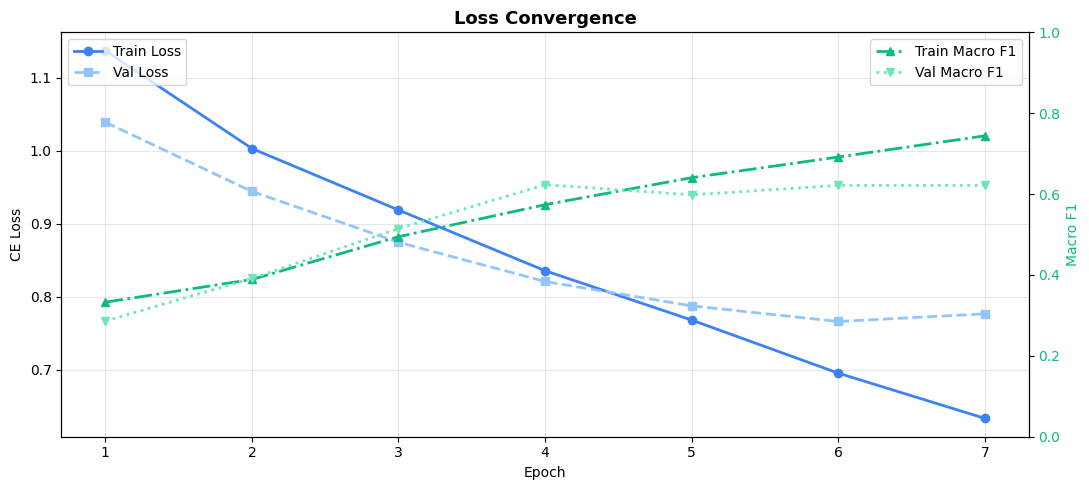

Saved: /kaggle/working/m2_labels-4cls_loss_convergence.png


In [20]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(epochs_range, history['train_loss'], 'o-',  color='#3b82f6', label='Train Loss', lw=2)
ax1.plot(epochs_range, history['val_loss'],   's--', color='#93c5fd', label='Val Loss',   lw=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('CE Loss'); ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_range, history['train_f1'], '^-.',  color='#10b981', label='Train Macro F1', lw=2)
ax2.plot(epochs_range, history['val_f1'],   'v:',   color='#6ee7b7', label='Val Macro F1',   lw=2)
ax2.set_ylabel('Macro F1', color='#10b981')
ax2.tick_params(axis='y', labelcolor='#10b981')
ax2.set_ylim([0, 1]); ax2.legend(loc='upper right')

plt.title('Loss Convergence', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(LOSS_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {LOSS_PLOT_PATH}')

---
## Section 11: Evaluasi Test Set

In [21]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.to(device)
print(f'Loaded best model from epoch {best_epoch}')

test_loss, test_m, test_true, test_pred = eval_epoch(model, test_loader, device)

print('\n' + '='*65)
print('TEST SET RESULTS')
print('='*65)
print(f'Test CE Loss          : {test_loss:.4f}')
print(f'Accuracy  (Pers. 2.15) : {test_m["accuracy"]:.4f}')
print(f'Macro Precision        : {test_m["macro_prec"]:.4f}')
print(f'Macro Recall           : {test_m["macro_rec"]:.4f}')
print(f'Macro F1   (Pers. 2.14): {test_m["macro_f1"]:.4f}')

Loaded best model from epoch 4


Eval :   0%|          | 0/4 [00:00<?, ?it/s]


TEST SET RESULTS
Test CE Loss          : 0.7822
Accuracy  (Pers. 2.15) : 0.6960
Macro Precision        : 0.6960
Macro Recall           : 0.5207
Macro F1   (Pers. 2.14): 0.5489


In [22]:
per_asp = compute_per_aspect_metrics(test_true, test_pred)

print('\nPer-Aspect Results:')
print(f'{"Aspect":<14} {"F1":>8} {"Prec":>8} {"Rec":>8} {"Acc":>8} {"N":>5}')
print('-'*55)
for r in per_asp:
    print(f'{r["aspect"]:<14} {r["f1"]:>8.4f} {r["precision"]:>8.4f} '
          f'{r["recall"]:>8.4f} {r["accuracy"]:>8.4f} {r["n_active"]:>5}')
avg_f1 = float(np.mean([r['f1'] for r in per_asp]))
print('-'*55)
print(f'{"MACRO AVG":<14} {avg_f1:>8.4f}')


Per-Aspect Results:
Aspect               F1     Prec      Rec      Acc     N
-------------------------------------------------------
PIGMENTATION     0.6325   0.6728   0.6222   0.6800    50
LONGEVITY        0.3734   0.4457   0.3611   0.8000    50
TEXTURE          0.3317   0.5105   0.3467   0.5200    50
HYDRATION        0.2893   0.5293   0.3007   0.6200    50
PRICE            0.8133   0.7937   0.8450   0.8600    50
-------------------------------------------------------
MACRO AVG        0.4880


Global Classification Report:
              precision    recall  f1-score   support

   no_aspect     0.8151    0.7578    0.7854       128
    negative     0.8000    0.2857    0.4211        28
     neutral     0.6000    0.2143    0.3158        14
    positive     0.5690    0.8250    0.6735        80

    accuracy                         0.6960       250
   macro avg     0.6960    0.5207    0.5489       250
weighted avg     0.7226    0.6960    0.6825       250



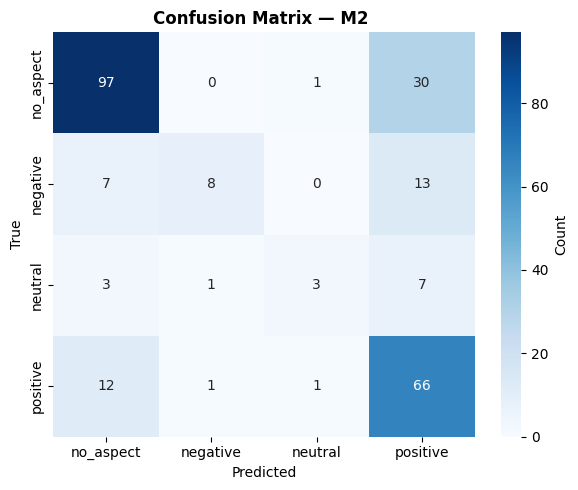

Saved: /kaggle/working/m2_labels-4cls_confusion_matrix.png


In [23]:
from sklearn.metrics import confusion_matrix

flat_true   = test_true.flatten()
flat_pred   = test_pred.flatten()

print('Global Classification Report:')
print(classification_report(flat_true, flat_pred,
      target_names=SENTIMENTS, digits=4, zero_division=0))

cm = confusion_matrix(flat_true, flat_pred, labels=[0, 1, 2, 3])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SENTIMENTS, yticklabels=SENTIMENTS,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix — M2 ', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig(CM_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {CM_PLOT_PATH}')

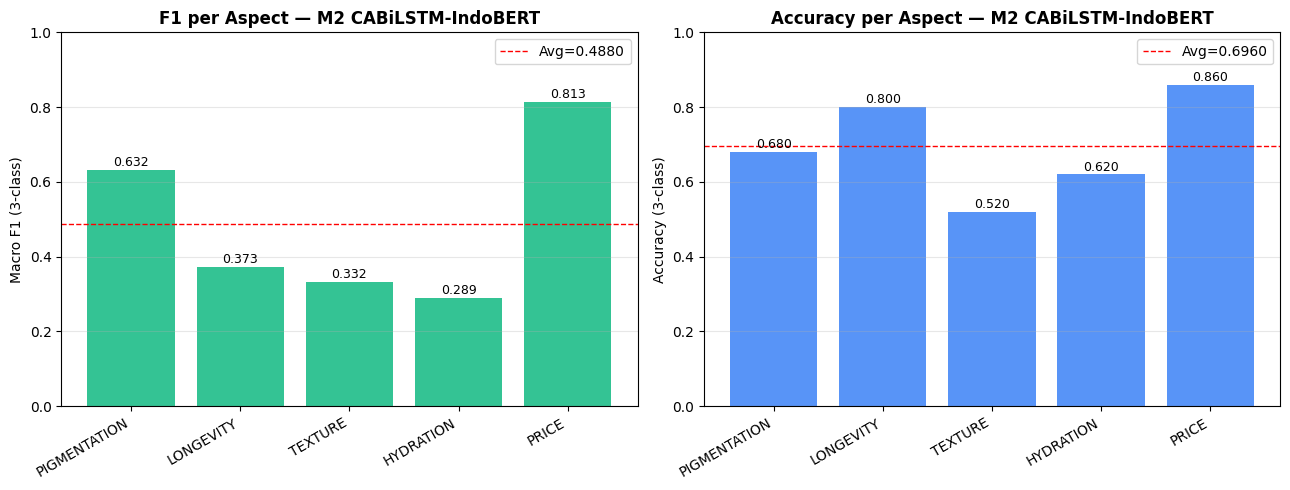

Saved: /kaggle/working/m2_labels-4cls_per_aspect_results.png


In [24]:
# ── Per-aspect F1 bar chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(ASPECTS))

f1_vals  = [r['f1']       for r in per_asp]
acc_vals = [r['accuracy'] for r in per_asp]

for ax, vals, ylabel, color in zip(
        axes,
        [f1_vals, acc_vals],
        ['Macro F1 (3-class)', 'Accuracy (3-class)'],
        ['#10b981', '#3b82f6']):
    bars = ax.bar(x, vals, color=color, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(ASPECTS, rotation=30, ha='right')
    ax.set_ylabel(ylabel); ax.set_ylim([0, 1])
    ax.axhline(np.mean(vals), color='red', linestyle='--', linewidth=1,
               label=f'Avg={np.mean(vals):.4f}')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)

axes[0].set_title('F1 per Aspect — M2 CABiLSTM-IndoBERT', fontweight='bold')
axes[1].set_title('Accuracy per Aspect — M2 CABiLSTM-IndoBERT', fontweight='bold')
plt.tight_layout()
plt.savefig(PERASPECT_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PERASPECT_PLOT_PATH}')

---
## Section 12: Hamming Loss (Proposal Persamaan 2.16)

In [25]:
D = test_true.shape[0]  # reviews
L = test_true.shape[1]  # aspects = 5

mismatches   = (test_true != test_pred).sum()
hamming_loss = mismatches / (D * L)

print('='*55)
print('HAMMING LOSS (Proposal Persamaan 2.16)')
print('='*55)
print(f'|D| (reviews) : {D}')
print(f'|L| (aspects) : {L}')
print(f'Mismatches    : {mismatches}')
print(f'Hamming Loss  : {mismatches}/{D*L} = {hamming_loss:.4f}')
print(f'Hamming Acc   : {1 - hamming_loss:.4f}')

print('\nPer-Aspect Hamming Loss:')
print(f'{"Aspect":<14} {"Mismatch":>10} {"HL":>8} {"HA":>8}')
print('-'*44)
per_asp_hl = []
for i, asp in enumerate(ASPECTS):
    mm = int((test_true[:, i] != test_pred[:, i]).sum())
    hl = mm / D
    per_asp_hl.append(hl)
    print(f'{asp:<14} {mm:>10} {hl:>8.4f} {1-hl:>8.4f}')
print('-'*44)
print(f'{"MACRO AVG":<14} {"":>10} {np.mean(per_asp_hl):>8.4f} {1-np.mean(per_asp_hl):>8.4f}')

HAMMING LOSS (Proposal Persamaan 2.16)
|D| (reviews) : 50
|L| (aspects) : 5
Mismatches    : 76
Hamming Loss  : 76/250 = 0.3040
Hamming Acc   : 0.6960

Per-Aspect Hamming Loss:
Aspect           Mismatch       HL       HA
--------------------------------------------
PIGMENTATION           16   0.3200   0.6800
LONGEVITY              10   0.2000   0.8000
TEXTURE                24   0.4800   0.5200
HYDRATION              19   0.3800   0.6200
PRICE                   7   0.1400   0.8600
--------------------------------------------
MACRO AVG                   0.3040   0.6960


---
## Section 13: Save Predictions & Metrics

In [26]:
# ── Predictions CSV ───────────────────────────────────────────────────────────
pred_rows = [
    {
        'review_id' : test_df.iloc[i]['review_id'],
        'aspect'    : asp,
        'true_label': ID2SENT.get(test_true[i, j], 'no_aspect'),
        'pred_label': ID2SENT.get(test_pred[i, j], 'no_aspect'),
        'correct'   : test_true[i, j] == test_pred[i, j],
    }
    for i in range(len(test_df))
    for j, asp in enumerate(ASPECTS)
]
pd.DataFrame(pred_rows).to_csv(PREDICTIONS_PATH, index=False)
print(f'Predictions saved: {PREDICTIONS_PATH}')

# ── Metrics JSON ──────────────────────────────────────────────────────────────
metrics_out = {
    'model'        : 'M2_CABiLSTM_IndoBERT_Multilabel_CE_4ASC',
    'config'       : CONFIG,
    'best_epoch'   : int(best_epoch),
    'best_val_f1'  : float(best_val_f1),
    'test_loss'    : float(test_loss),
    'test_accuracy': float(test_m['accuracy']),
    'test_macro_f1'  : float(test_m['macro_f1']),
    'test_macro_prec': float(test_m['macro_prec']),
    'test_macro_rec' : float(test_m['macro_rec']),
    'per_aspect'     : per_asp,
    'avg_per_aspect_f1': float(avg_f1),
    'hamming_loss'   : {
        'formula'         : 'Proposal Persamaan 2.16',
        'D_reviews'       : int(D),
        'L_aspects'       : int(L),
        'overall'         : float(hamming_loss),
        'hamming_accuracy': float(1 - hamming_loss),
        'per_aspect'      : {asp: float(hl) for asp, hl in zip(ASPECTS, per_asp_hl)},
    },
    'history': {k: [float(v) for v in vs] for k, vs in history.items()},
}
with open(METRICS_PATH, 'w') as f:
    json.dump(metrics_out, f, indent=2, default=str)
print(f'Metrics  saved: {METRICS_PATH}')

print('\n' + '='*55)
print(f'✅ M2 complete — Test Macro F1: {test_m["macro_f1"]:.4f}')
print('='*55)

Predictions saved: /kaggle/working/m2_labels-4cls_predictions.csv
Metrics  saved: /kaggle/working/m2_labels-4cls_metrics.json

✅ M2 complete — Test Macro F1: 0.5489
